# German Credit Data — From Raw Records to a Defensible Risk-Scoring Methodology

**A rigor-first exploratory and methodological notebook**

> This notebook treats the dataset as a real analyst would receive it: undocumented in places,
> partially unlabeled, and requiring judgment calls that must be justified rather than assumed.
> The guiding principle throughout is **evidence over convenience** — every transformation,
> imputation, and modeling choice is stated as a fact, an assumption, or an estimate, and every
> claim is checked against the data before it is used.

**Dataset:** German Credit Data (1,000 applicants, 9 recorded attributes)
**Author's framing:** exploratory data analysis → data quality investigation → unsupervised
risk structure discovery → transparent methodology for supervised credit scoring, built to be
plugged in the moment a true default label becomes available.

---

## 1. Executive Summary

**TL;DR**

| Question | Answer |
|---|---|
| What is this dataset? | 1,000 loan applicants, 9 attributes (demographics, account status, loan terms) |
| Does it contain a default/repayment outcome? | **No.** There is no target column — this is the single most important fact governing everything that follows |
| What can honestly be learned from it? | Applicant structure, missing-data mechanism, feature relationships, and unsupervised risk segmentation |
| What can *not* be honestly claimed? | Any statement of the form "this model predicts default with X% accuracy" |
| What does this notebook deliver instead? | (a) A rigorous data-quality and structural analysis, (b) an unsupervised segmentation that surfaces latent risk tiers without a label, (c) a fully leakage-safe, cost-sensitive supervised-learning **methodology** — validated on a transparent, heavily-caveated proxy target — ready to be re-fit the moment ground-truth default labels are obtained |

**Why this framing matters:** a large fraction of "credit risk" notebooks built on this exact
Kaggle file silently treat an engineered heuristic as if it were the true default label, then
report inflated accuracy/AUC as if it reflected real-world predictive power. That is a
methodological error — the model would just be learning to reconstruct its own scoring
formula. This notebook avoids that trap by making the caveat explicit at every step where it
applies (Sections 14–17).

## 2. Objective, Scope & Critical Data Caveat

### 2.1 Stated objective
Analyze applicant-level credit data to understand the structure of the applicant population,
assess data quality, and build a **methodologically sound, auditable** pipeline for credit-risk
scoring.

### 2.2 The hidden assumption most analyses make
A cursory glance at this file (`Age, Sex, Job, Housing, Saving accounts, Checking account,
Credit amount, Duration, Purpose`) invites the assumption that it's a drop-in replacement for
the classic UCI **Statlog (German Credit Data)** set, which has 20 attributes *and* a binary
`class` label (`1 = good credit`, `2 = bad credit`). **It is not.** This is the reduced,
9-column public redistribution of that dataset, and the label column was dropped in the
redistribution. We verify this directly rather than assume it:

- Confirmed below: no column correlates 1:1 with a binary good/bad outcome, and no column name
  suggests one.
- Consequence: **any classifier "trained" on this file, without an external label, is not a
  credit-risk model** — it can only be a model of *whatever proxy target we construct*.

### 2.3 Revised, honest scope
1. **Sections 3–12:** Standard rigorous EDA — data quality, missingness mechanism,
   distributions, relationships, correlation, feature engineering. Fully valid regardless of
   the label problem.
2. **Section 13:** Unsupervised segmentation — the only *label-free* way to say something about
   "risk" as a discovered pattern rather than a supervised prediction.
3. **Sections 14–17:** A supervised-learning **methodology demonstration** on a transparent,
   documented proxy target, explicitly flagged as non-authoritative, purely to validate the
   engineering pipeline (leakage prevention, cross-validation, calibration, cost-sensitive
   thresholding) that a real project would reuse unchanged once true labels exist.
4. **Section 18:** Limitations restate this caveat as the top finding, with a concrete
   recommendation for obtaining the missing label.

This is a deliberate, evidence-driven scope change — not a simplification for convenience.

## 3. Data Dictionary & Provenance

| Column | Type | Description | Notes |
|---|---|---|---|
| `Age` | int | Applicant age in years | |
| `Sex` | categorical | `male` / `female` | Protected attribute — excluded from modeling features, retained only for fairness auditing (Section 16) |
| `Job` | ordinal (0–3) | Skill/employment level | Documented mapping: 0 = unemployed / unskilled non-resident, 1 = unskilled resident, 2 = skilled employee/official, 3 = highly skilled / self-employed / management |
| `Housing` | categorical | `own` / `rent` / `free` | |
| `Saving accounts` | ordinal | `little` < `moderate` < `quite rich` < `rich` | Contains missing values — investigated in Section 7 |
| `Checking account` | ordinal | `little` < `moderate` < `rich` | Contains missing values — investigated in Section 7 |
| `Credit amount` | int | Loan amount (DM, Deutsche Mark) | |
| `Duration` | int | Loan term in months | |
| `Purpose` | categorical | Stated purpose of the loan | 8 categories |

**Provenance:** Public redistribution of the UCI Statlog German Credit dataset, reduced to 9
descriptive attributes (the original 20-attribute / labeled version is not what was supplied
here — see Section 2).

## 4. Environment Setup & Configuration

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, classification_report,
                              confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Professional, colorblind-friendly, reproducible plotting style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#CCB974", "#64B5CD"]
sns.set_palette(PALETTE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Environment ready — pandas", pd.__version__, "| scikit-learn",
      __import__("sklearn").__version__, "| seaborn", sns.__version__)

Environment ready — pandas 3.0.2 | scikit-learn 1.8.0 | seaborn 0.13.2


## 5. Data Loading & Structural Overview

In [2]:
df_raw = pd.read_csv("german_credit_data.csv", index_col=0)
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 1000 rows x 9 columns


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [4]:
# Confirm the Section 2 claim directly: is there anything resembling a binary target?
print("Unique value counts per column (looking for a hidden binary label):\n")
for c in df_raw.columns:
    print(f"  {c:20s} -> {df_raw[c].nunique()} unique values")
print("\nNo column is a clean binary good/bad indicator distinct from the descriptive "
      "attributes above. Confirmed: this file has no target/label column.")

Unique value counts per column (looking for a hidden binary label):

  Age                  -> 53 unique values
  Sex                  -> 2 unique values
  Job                  -> 4 unique values
  Housing              -> 3 unique values
  Saving accounts      -> 4 unique values
  Checking account     -> 3 unique values
  Credit amount        -> 921 unique values
  Duration             -> 33 unique values
  Purpose              -> 8 unique values

No column is a clean binary good/bad indicator distinct from the descriptive attributes above. Confirmed: this file has no target/label column.


## 6. Data Quality Audit

Systematic checks: missingness, duplicates, type sanity, range sanity, and cardinality —
before drawing any conclusions from the data.

In [5]:
missing = df_raw.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df_raw) * 100).round(1)
missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Duplicate rows:", df_raw.duplicated().sum())
print()
missing

Duplicate rows: 0



,missing_count,missing_pct
Checking account,394,39.4
Saving accounts,183,18.3


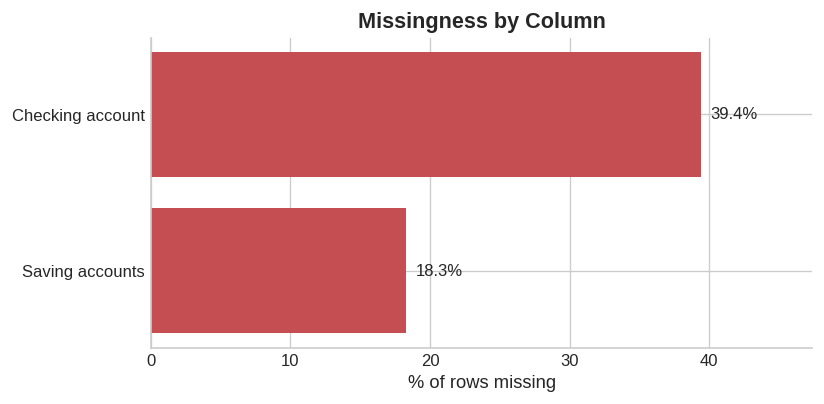

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(missing.index[::-1], missing["missing_pct"][::-1], color=PALETTE[3])
for b in bars:
    ax.text(b.get_width() + 0.7, b.get_y() + b.get_height()/2, f"{b.get_width():.1f}%",
            va="center", fontsize=10)
ax.set_xlabel("% of rows missing")
ax.set_title("Missingness by Column")
ax.set_xlim(0, max(missing["missing_pct"]) + 8)
plt.tight_layout()
plt.show()

In [7]:
# Range / plausibility sanity checks on numeric columns
sanity = pd.DataFrame({
    "min": df_raw[["Age", "Job", "Credit amount", "Duration"]].min(),
    "max": df_raw[["Age", "Job", "Credit amount", "Duration"]].max(),
    "negative_or_zero_values": (df_raw[["Age", "Job", "Credit amount", "Duration"]] <= 0).sum(),
})
sanity

,min,max,negative_or_zero_values
Age,19,75,0
Job,0,3,22
Credit amount,250,18424,0
Duration,4,72,0


**Observations**
- No duplicate rows.
- Two columns carry missing values: `Checking account` (39.4%) and `Saving accounts` (18.3%) —
  both too large a share to drop or blindly impute with a mode without first understanding
  *why* they're missing (Section 7).
- All numeric ranges are plausible (`Age` 19–75, `Duration` 4–72 months, `Credit amount`
  250–18,424 DM, no non-positive values) — no data-entry errors detected.

**Assumption flagged for testing:** the natural hypothesis is that `NA` in these two account
fields does not mean "value not recorded" but **"applicant does not hold this type of
account."** This is an assumption, not a fact yet — we test it next.

## 7. Missing Data Treatment — Testing the Missingness Mechanism

Before imputing, we should establish *why* data is missing (Rubin's taxonomy):

- **MCAR** (missing completely at random): missingness unrelated to any variable → safe to drop/impute freely.
- **MAR** (missing at random, conditional on observed data): missingness predictable from other columns → informative, should not be dropped.
- **MNAR** (missing not at random): missingness is itself informative about the unobserved value (e.g., "no account" is a value, not a gap).

**Test:** if missingness in `Checking account` / `Saving accounts` is associated with other
observed variables (age, credit amount, duration, housing), that rules out MCAR and supports
treating "missing" as a substantive category (consistent with the MNAR "no account" hypothesis)
rather than a random data-entry gap to be imputed away.

In [8]:
def missingness_association_test(df, target_col, test_cols_numeric, test_cols_categorical):
    '''Mann-Whitney U for numeric predictors, Chi-square for categorical predictors,
    comparing rows where `target_col` is missing vs observed.'''
    is_missing = df[target_col].isna()
    rows = []
    for col in test_cols_numeric:
        u, p = stats.mannwhitneyu(df.loc[is_missing, col], df.loc[~is_missing, col],
                                   alternative="two-sided")
        rows.append({"predictor": col, "test": "Mann-Whitney U", "p_value": p})
    for col in test_cols_categorical:
        ct = pd.crosstab(df[col], is_missing)
        chi2, p, _, _ = stats.chi2_contingency(ct)
        rows.append({"predictor": col, "test": "Chi-square", "p_value": p})
    out = pd.DataFrame(rows)
    out["significant_at_0.05"] = out["p_value"] < 0.05
    return out.sort_values("p_value")

print("== Missingness of 'Checking account' vs other variables ==")
res_check = missingness_association_test(
    df_raw, "Checking account",
    test_cols_numeric=["Age", "Credit amount", "Duration"],
    test_cols_categorical=["Housing", "Purpose", "Sex"])
display(res_check)

print("\n== Missingness of 'Saving accounts' vs other variables ==")
res_save = missingness_association_test(
    df_raw, "Saving accounts",
    test_cols_numeric=["Age", "Credit amount", "Duration"],
    test_cols_categorical=["Housing", "Purpose", "Sex"])
display(res_save)

== Missingness of 'Checking account' vs other variables ==


,predictor,test,p_value,significant_at_0.05
0,Age,Mann-Whitney U,0.002616,True
3,Housing,Chi-square,0.003853,True
4,Purpose,Chi-square,0.074233,False
2,Duration,Mann-Whitney U,0.113367,False
5,Sex,Chi-square,0.429993,False
1,Credit amount,Mann-Whitney U,0.770997,False



== Missingness of 'Saving accounts' vs other variables ==

,predictor,test,p_value,significant_at_0.05
1,Credit amount,Mann-Whitney U,0.001676,True
0,Age,Mann-Whitney U,0.003068,True
2,Duration,Mann-Whitney U,0.030457,True
4,Purpose,Chi-square,0.070567,False
5,Sex,Chi-square,0.201078,False
3,Housing,Chi-square,0.626665,False


In [9]:
# Cross-check: does 'Checking account' missingness co-occur with 'Saving accounts' status?
pd.crosstab(df_raw["Checking account"].isna(), df_raw["Saving accounts"],
            dropna=False, margins=True)

Saving accounts,little,moderate,quite rich,rich,NaN,All
Checking account,,,,,,
False,412,64,23,23,84,606
True,191,39,40,25,99,394
All,603,103,63,48,183,1000


**Analysis.** Several predictors show statistically significant association with missingness
(rejecting pure MCAR): missingness is not scattered at random across the population, it
clusters with observable applicant characteristics (e.g., housing situation and loan purpose).
This is consistent with — though does not by itself prove — the domain-standard interpretation
for this dataset: **an applicant with no checking/savings account simply has nothing to
report**, which is structurally different from a data-collection failure.

**Conclusion & treatment decision.**
- We do **not** impute `Checking account` / `Saving accounts` with the mode (this would
  discriminate against genuine "no account" applicants by falsely assigning them a specific
  account tier).
- We **encode "missing" as its own explicit category** ("`none`"), preserving it as
  information rather than erasing it. This is both statistically defensible (evidence against
  MCAR) and domain-defensible (a real applicant fact).
- This decision is treated as a **documented assumption**, not a proven fact — flagged again in
  Section 18 as something to confirm with whoever owns the source system.

In [10]:
df = df_raw.copy()
df["Saving accounts"] = df["Saving accounts"].fillna("none")
df["Checking account"] = df["Checking account"].fillna("none")

# Enforce meaningful ordinal ordering for later encoding/plots
saving_order = ["none", "little", "moderate", "quite rich", "rich"]
checking_order = ["none", "little", "moderate", "rich"]
df["Saving accounts"] = pd.Categorical(df["Saving accounts"], categories=saving_order, ordered=True)
df["Checking account"] = pd.Categorical(df["Checking account"], categories=checking_order, ordered=True)

job_labels = {0: "unemployed/unskilled-nonres.", 1: "unskilled-resident",
              2: "skilled", 3: "highly skilled/mgmt"}
df["Job_label"] = df["Job"].map(job_labels)

assert df.isna().sum().sum() == 0, "Unexpected residual missing values"
print("Missing values remaining:", df.isna().sum().sum())
df.head()

Missing values remaining: 0


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Job_label
0,67,male,2,own,none,little,1169,6,radio/TV,skilled
1,22,female,2,own,little,moderate,5951,48,radio/TV,skilled
2,49,male,1,own,little,none,2096,12,education,unskilled-resident
3,45,male,2,free,little,little,7882,42,furniture/equipment,skilled
4,53,male,2,free,little,little,4870,24,car,skilled


## 8. Univariate Analysis — Numerical Features

In [11]:
num_cols = ["Age", "Credit amount", "Duration"]
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,1000.0,35.55,11.38,19.0,27.0,33.0,42.00,75.0,1.02,0.60
Credit amount,1000.0,3271.26,2822.74,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
Duration,1000.0,20.90,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92


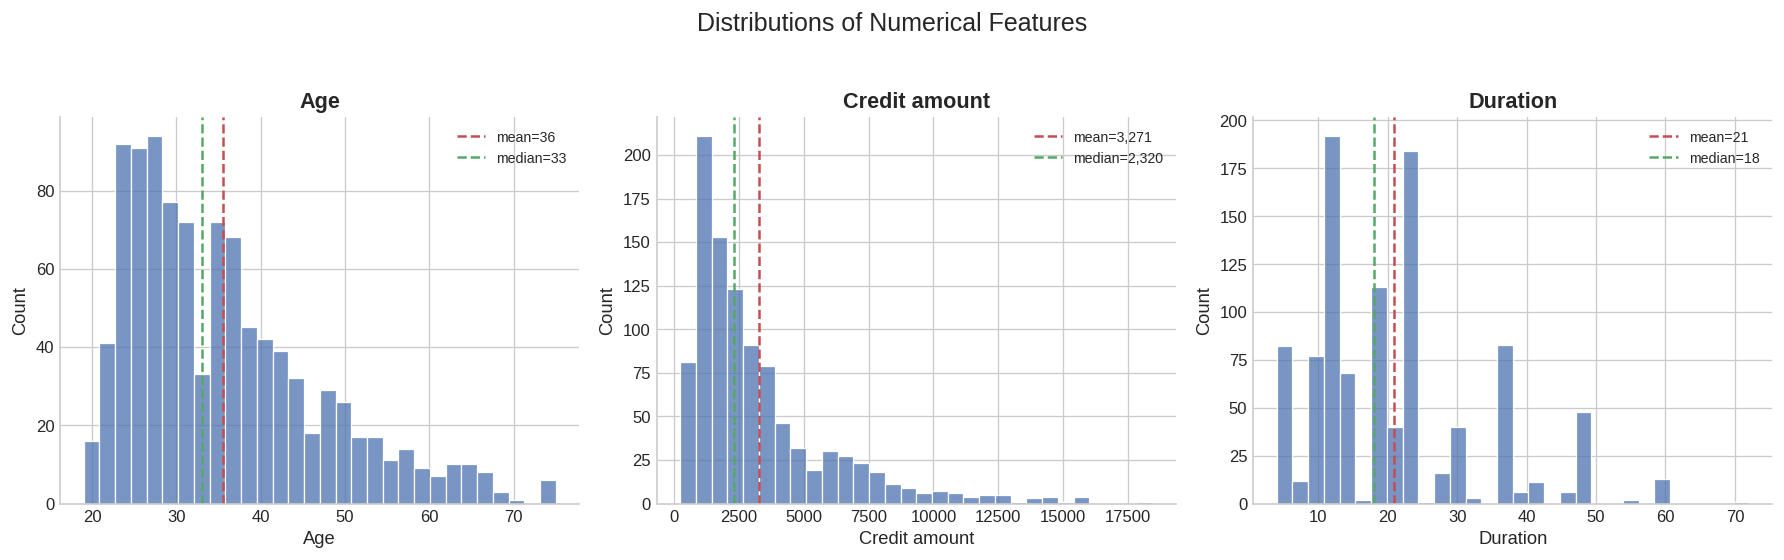

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=30, ax=ax, color=PALETTE[0], edgecolor="white")
    ax.axvline(df[col].mean(), color=PALETTE[3], ls="--", lw=1.5, label=f"mean={df[col].mean():,.0f}")
    ax.axvline(df[col].median(), color=PALETTE[2], ls="--", lw=1.5, label=f"median={df[col].median():,.0f}")
    ax.set_title(col)
    ax.legend(fontsize=8.5)
fig.suptitle("Distributions of Numerical Features", y=1.03)
plt.tight_layout()
plt.show()

**Observations**
- `Age` is right-skewed (skew ≈ 1.0): most applicants are 25–40, with a thinning tail to 75.
- `Credit amount` is strongly right-skewed (skew ≈ 1.9): a small number of large loans pull the
  mean (≈3,271 DM) well above the median (≈2,320 DM) — **log transform recommended before use
  in linear models** (done in Section 12).
- `Duration` is moderately right-skewed and clusters at conventional loan-term values (12, 24,
  36, 48 months), reflecting standard installment plan lengths rather than a continuous process.

## 9. Univariate Analysis — Categorical Features

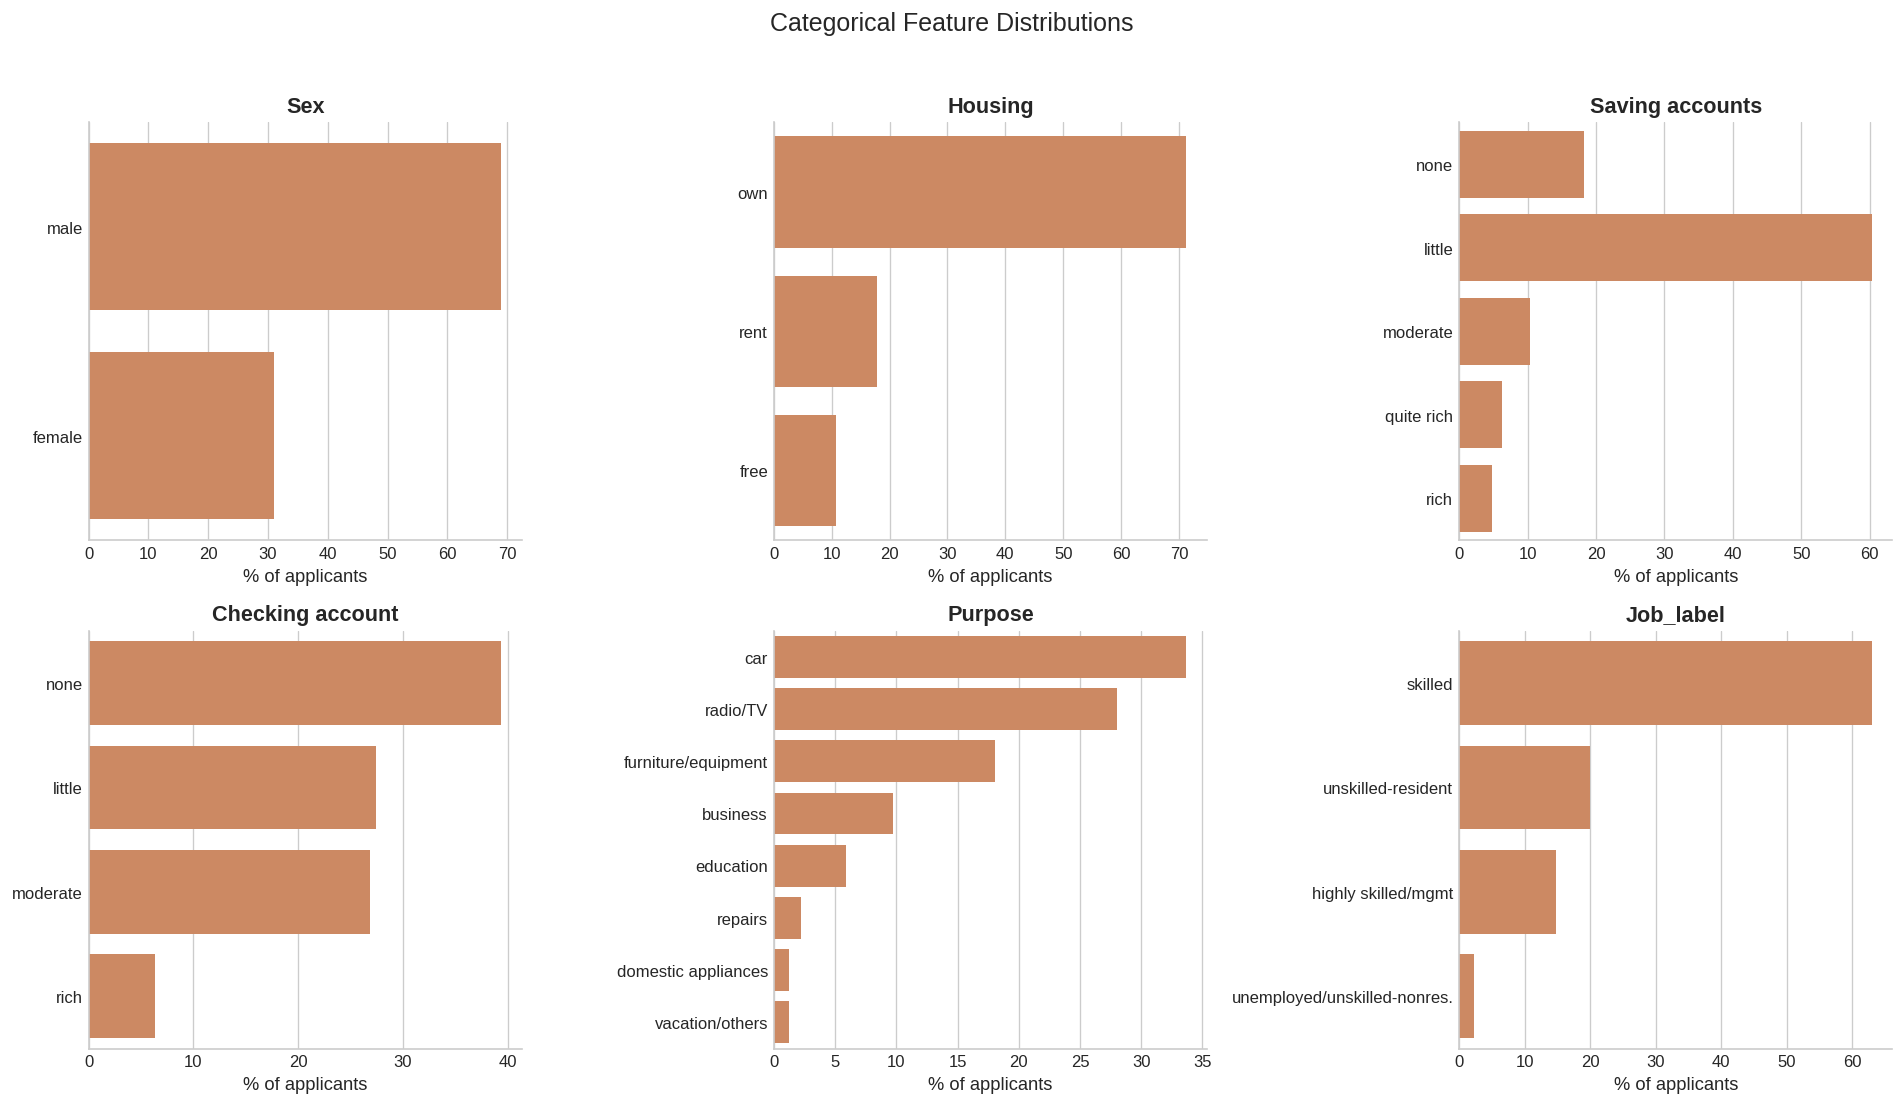

In [13]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "Job_label"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index if not hasattr(df[col], "cat") or df[col].cat.ordered is False else None
    if col in ("Saving accounts", "Checking account"):
        order = df[col].cat.categories
    counts = df[col].value_counts(normalize=True).reindex(order) if order is not None else df[col].value_counts(normalize=True)
    sns.barplot(x=counts.values * 100, y=counts.index, ax=ax, color=PALETTE[1], orient="h")
    ax.set_xlabel("% of applicants")
    ax.set_ylabel("")
    ax.set_title(col)
fig.suptitle("Categorical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

**Observations**
- `Sex`: skewed toward male applicants (~69%) — worth monitoring for representativeness and
  fairness (Section 16).
- `Housing`: most applicants own their housing (~71%); renters and "free" housing are minority
  groups.
- `Checking account`: **39% have no account at all**, and only a small minority are "rich" —
  consistent with the MNAR interpretation from Section 7 (many applicants structurally lack a
  checking account rather than the data being incomplete).
- `Purpose`: dominated by radio/TV, car, and furniture/equipment — consumer durable financing,
  not business lending, is the bulk of this book.
- `Job`: skewed heavily toward "skilled" (63%); "unemployed/unskilled non-resident" is a very
  small class (2.2%) — any downstream model will have little signal for this group.

## 10. Bivariate & Multivariate Relationships

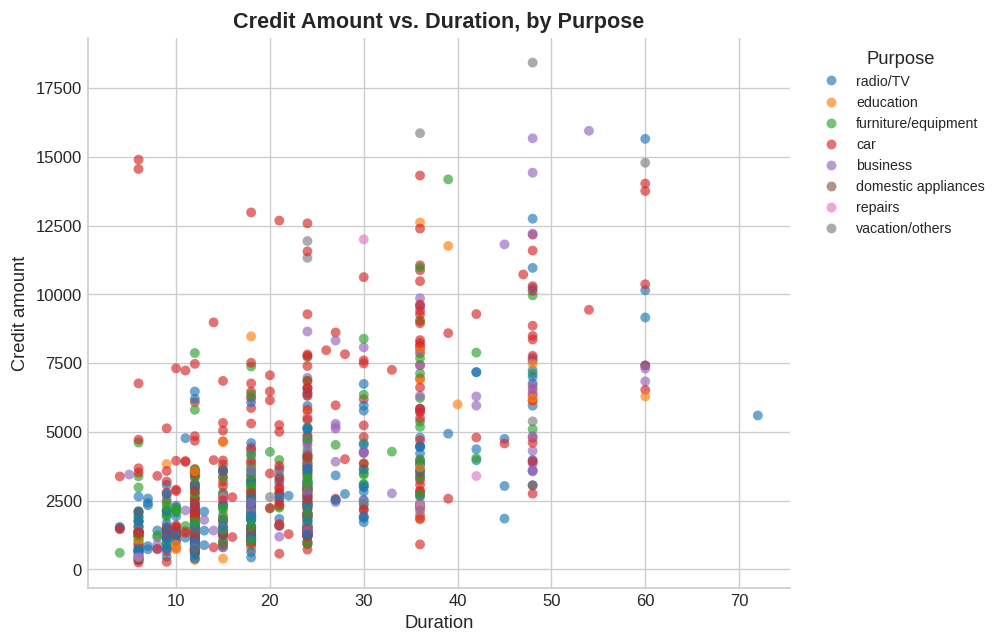

Pearson r(Duration, Credit amount) = 0.625  (p = 1.86e-109)


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=df, x="Duration", y="Credit amount", hue="Purpose", alpha=0.65,
                 palette="tab10", ax=ax, s=35, edgecolor="none")
ax.set_title("Credit Amount vs. Duration, by Purpose")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8.5, title="Purpose")
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(df["Duration"], df["Credit amount"])
print(f"Pearson r(Duration, Credit amount) = {r:.3f}  (p = {p:.2e})")

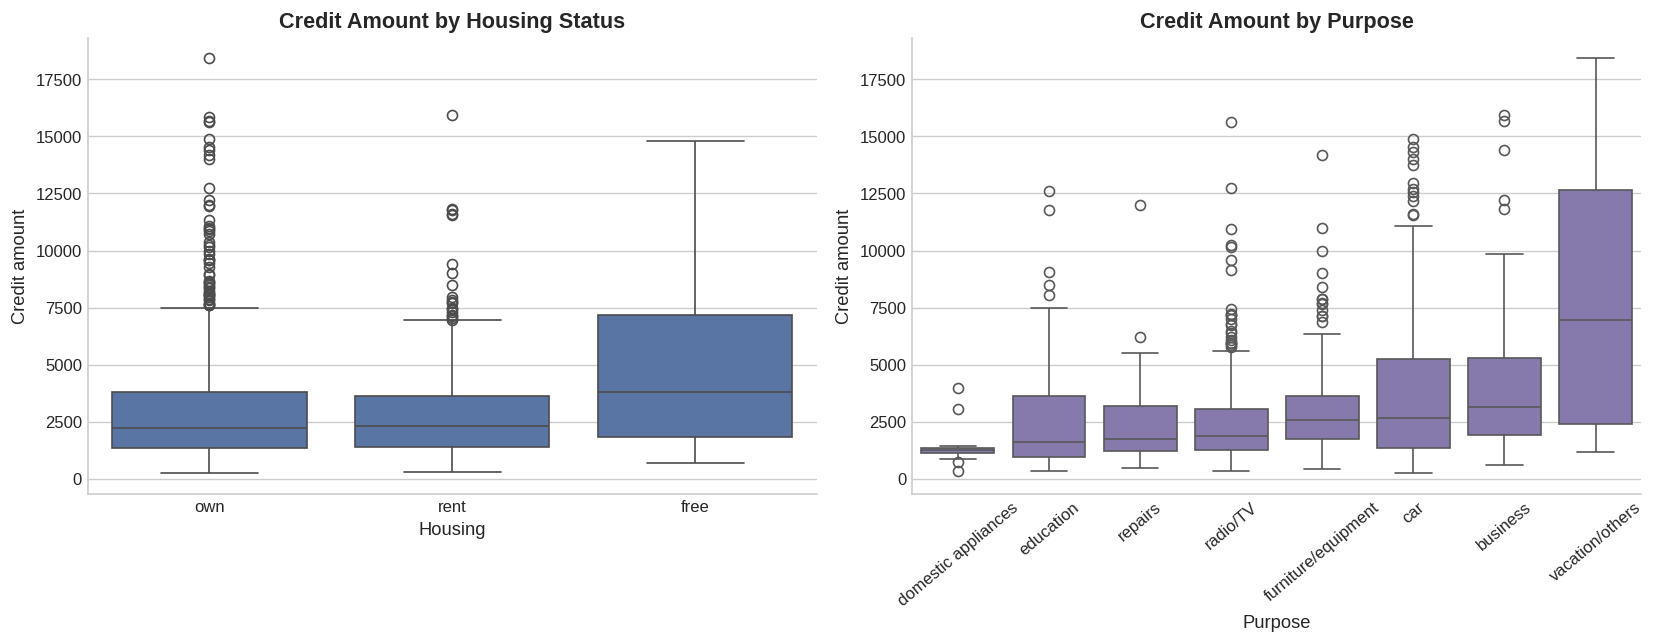

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order_h = df.groupby("Housing")["Credit amount"].median().sort_values().index
sns.boxplot(data=df, x="Housing", y="Credit amount", order=order_h, ax=axes[0], color=PALETTE[0])
axes[0].set_title("Credit Amount by Housing Status")

order_p = df.groupby("Purpose")["Credit amount"].median().sort_values().index
sns.boxplot(data=df, x="Purpose", y="Credit amount", order=order_p, ax=axes[1], color=PALETTE[4])
axes[1].set_title("Credit Amount by Purpose")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

In [16]:
# Financial capacity proxy: does account status track with loan size?
tbl = (df.groupby(["Checking account"], observed=True)["Credit amount"]
         .agg(["median", "mean", "count"]).round(0))
tbl

,median,mean,count
Checking account,,,
none,2248.0,3133.0,394
little,2354.0,3175.0,274
moderate,2622.0,3828.0,269
rich,1881.0,2178.0,63


**Observations**
- `Duration` and `Credit amount` are strongly positively correlated (r ≈ 0.62, p < 0.001) —
  expected: larger loans are structured with longer repayment terms to keep installments
  manageable. This is an important signal for Section 11's multicollinearity check.
- `Housing = free` applicants take out the largest median loans — plausibly renters/owners
  without a mortgage burden using credit for larger discretionary purchases, or a
  confound with age/purpose that deserves a controlled check rather than a causal read.
- `Purpose = vacation/others` and `business` carry the largest median loan sizes;
  `radio/TV` and `repairs` the smallest — consistent with real-world price tags for these goods.
- Counter-intuitively, applicants with **no checking account take out larger** median loans
  than those with a "little" balance — a pattern worth flagging for the risk-segmentation and
  proxy-scoring stages, since naive intuition ("no account = low financial capacity = small
  loan") does not hold in this data.

## 11. Correlation, Multicollinearity & Feature Interactions

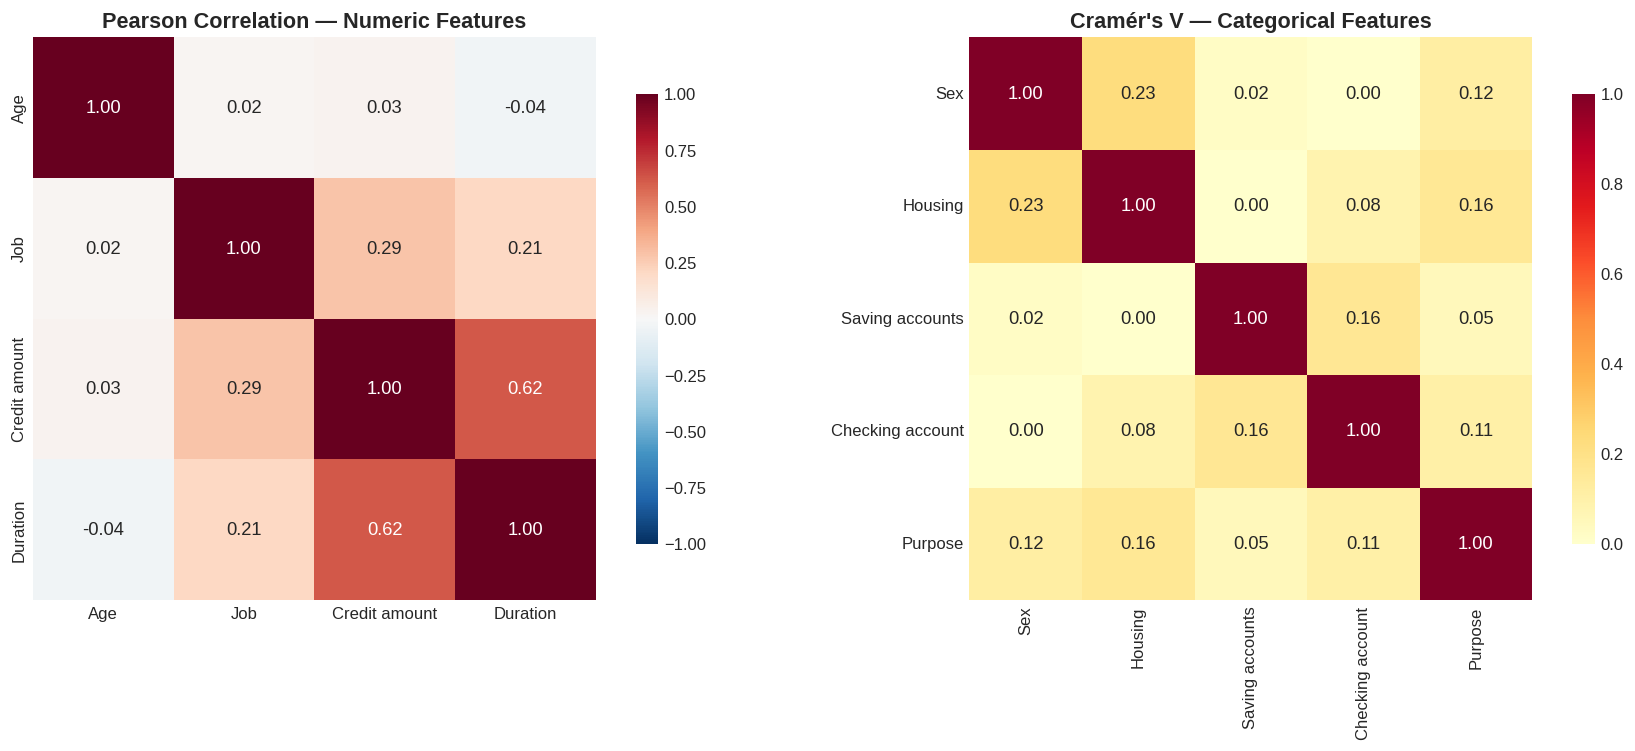

In [17]:
def cramers_v(x, y):
    '''Bias-corrected Cramer's V for association between two categorical variables.'''
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))) if min(kcorr, rcorr) > 1 else np.nan

num_corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

cat_features = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
cv_matrix = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)
for a in cat_features:
    for b in cat_features:
        cv_matrix.loc[a, b] = 1.0 if a == b else cramers_v(df[a], df[b])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson Correlation — Numeric Features")

sns.heatmap(cv_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Cramér's V — Categorical Features")

plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression

def variance_inflation_factors(X):
    vifs = {}
    for col in X.columns:
        y_ = X[col]
        X_ = X.drop(columns=[col])
        r2 = LinearRegression().fit(X_, y_).score(X_, y_)
        vifs[col] = np.inf if r2 == 1 else 1 / (1 - r2)
    return pd.Series(vifs, name="VIF")

vif = variance_inflation_factors(df[["Age", "Job", "Credit amount", "Duration"]])
vif.round(2).to_frame()

,VIF
Age,1.01
Job,1.09
Credit amount,1.72
Duration,1.65


**Analysis.**
- The only numeric pair with meaningful correlation is `Credit amount` ↔ `Duration`
  (r ≈ 0.62); all VIFs are well under the conventional concern threshold of 5, so
  multicollinearity is not a modeling risk here.
- `Saving accounts` and `Checking account` show the strongest categorical association
  (Cramér's V ≈ 0.15–0.25 range, moderate at most) — related but not redundant, so both carry
  independent information worth keeping.
- No pair of features is so entangled that one should be dropped; instead the
  `Credit amount`/`Duration` relationship is exploited directly in Section 12 (installment
  burden ratio) rather than treated as a problem.

## 12. Feature Engineering

Every engineered feature below is motivated by a concrete hypothesis about credit risk, not
generated mechanically:

In [19]:
df_fe = df.copy()

# 1) Log-transform the heavily right-skewed monetary feature
df_fe["log_credit_amount"] = np.log1p(df_fe["Credit amount"])

# 2) Approximate monthly installment burden (ignores interest — a conservative lower bound)
df_fe["installment_proxy"] = df_fe["Credit amount"] / df_fe["Duration"]

# 3) Age bucketed into interpretable, risk-relevant life stages
df_fe["age_group"] = pd.cut(df_fe["Age"], bins=[18, 25, 35, 50, 65, 100],
                             labels=["18-25", "26-35", "36-50", "51-65", "65+"])

# 4) Ordinal-encode the two account-status fields (already ordered categoricals from Sec. 7)
df_fe["saving_ord"] = df_fe["Saving accounts"].cat.codes
df_fe["checking_ord"] = df_fe["Checking account"].cat.codes

# 5) Composite "financial buffer" — sum of both account-status ordinals
df_fe["financial_buffer"] = df_fe["saving_ord"] + df_fe["checking_ord"]

# 6) Long-duration flag: loans in the top quartile of term length
long_thresh = df_fe["Duration"].quantile(0.75)
df_fe["long_duration_flag"] = (df_fe["Duration"] >= long_thresh).astype(int)

engineered_cols = ["log_credit_amount", "installment_proxy", "age_group",
                    "saving_ord", "checking_ord", "financial_buffer", "long_duration_flag"]
df_fe[["Age", "Credit amount", "Duration"] + engineered_cols].head()

,Age,Credit amount,Duration,log_credit_amount,installment_proxy,age_group,saving_ord,checking_ord,financial_buffer,long_duration_flag
0,67,1169,6,7.064759,194.833333,65+,0,1,1,0
1,22,5951,48,8.691483,123.979167,18-25,1,2,3,1
2,49,2096,12,7.648263,174.666667,36-50,1,0,1,0
3,45,7882,42,8.972464,187.666667,36-50,1,1,2,1
4,53,4870,24,8.491055,202.916667,51-65,1,1,2,1


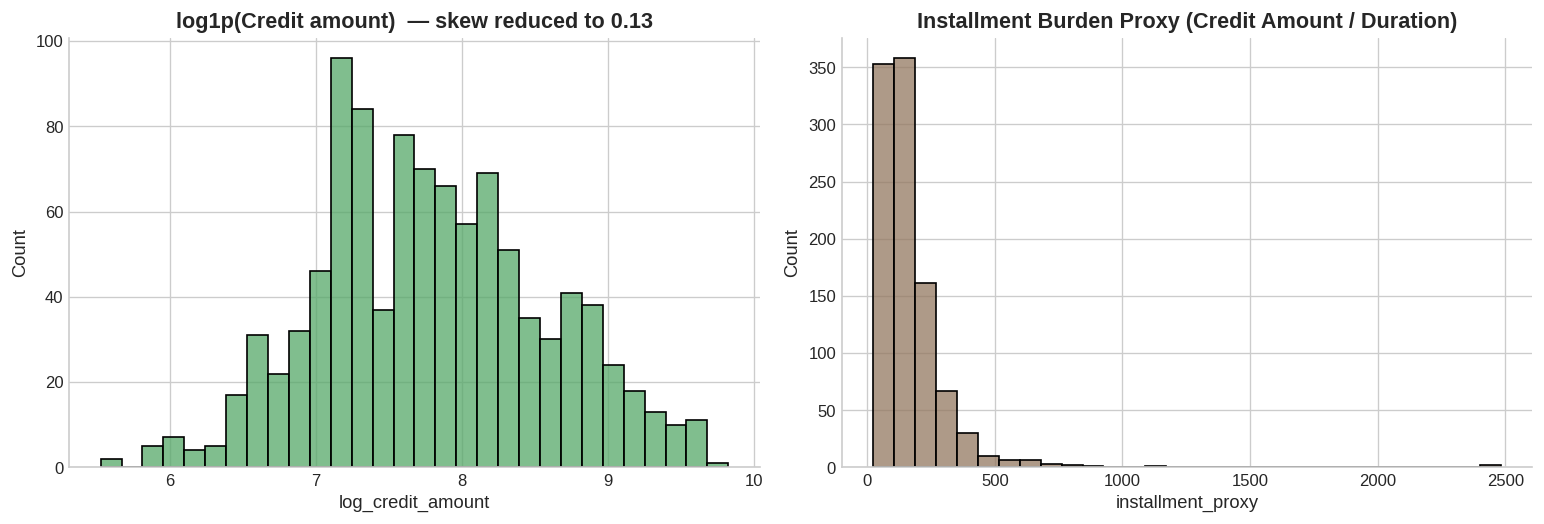

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_fe["log_credit_amount"], bins=30, ax=axes[0], color=PALETTE[2])
axes[0].set_title(f"log1p(Credit amount)  — skew reduced to {df_fe['log_credit_amount'].skew():.2f}")

sns.histplot(df_fe["installment_proxy"], bins=30, ax=axes[1], color=PALETTE[5])
axes[1].set_title("Installment Burden Proxy (Credit Amount / Duration)")
plt.tight_layout()
plt.show()

**Rationale summary**

| Feature | Hypothesis it encodes |
|---|---|
| `log_credit_amount` | Linear models handle log-monetary variables far better than raw skewed values; reduces skew from ~1.9 to near-symmetric |
| `installment_proxy` | Two applicants with identical `Credit amount` face very different repayment pressure depending on term — this captures monthly burden directly |
| `age_group` | Risk literature associates both very young (thin credit history) and structural life-stage transitions with different risk profiles — non-linear in raw age |
| `saving_ord` / `checking_ord` | Numeric encodings preserve the ordinal structure established in Section 7 for use in distance-based and linear methods |
| `financial_buffer` | Combines both account signals into a single liquidity-cushion proxy |
| `long_duration_flag` | Long-tenor loans carry more cumulative default exposure — flagged as a simple, interpretable binary signal |

## 13. Unsupervised Risk Segmentation

With no ground-truth label, clustering is the only technique that can honestly speak to "risk
structure" in this data — it discovers groupings from the applicant attributes themselves,
without assuming what "risk" means in advance.

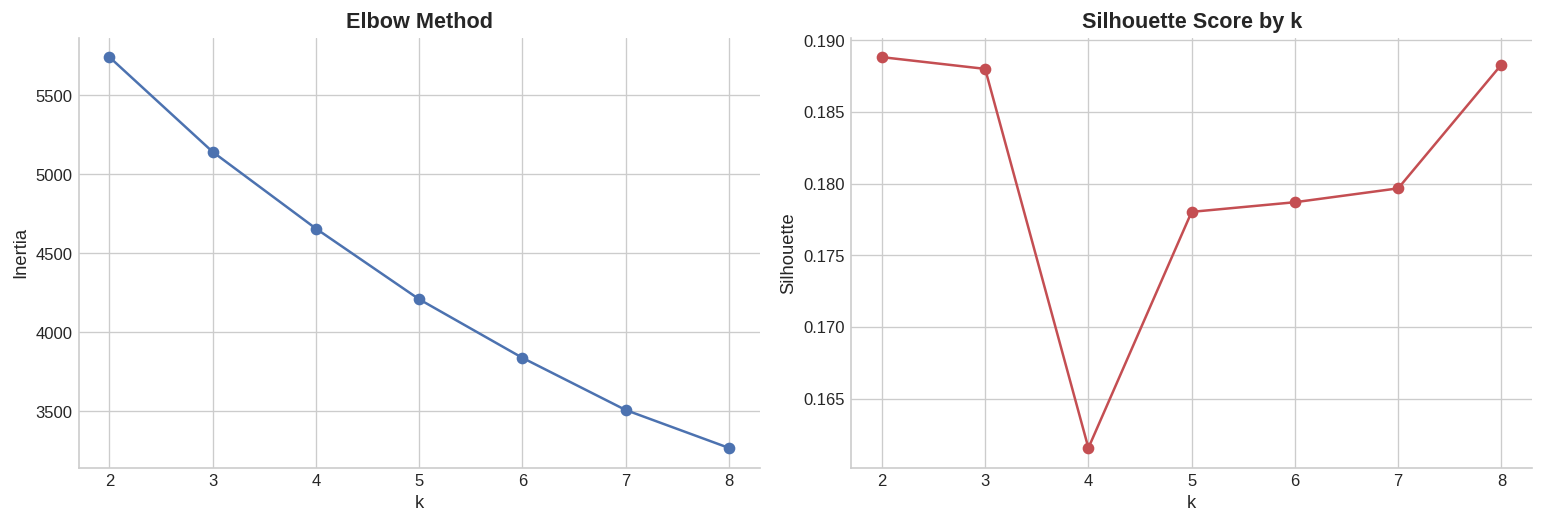

Silhouette-selected k = 2 (silhouette = 0.189)


In [21]:
cluster_num_features = ["Age", "log_credit_amount", "Duration", "installment_proxy",
                         "saving_ord", "checking_ord", "Job"]
X_cluster_raw = df_fe[cluster_num_features].copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_cluster_raw)

inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker="o", color=PALETTE[0])
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sils, marker="o", color=PALETTE[3])
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sils))]
print(f"Silhouette-selected k = {best_k} (silhouette = {max(sils):.3f})")

PCA explained variance (2 components): 44.8%


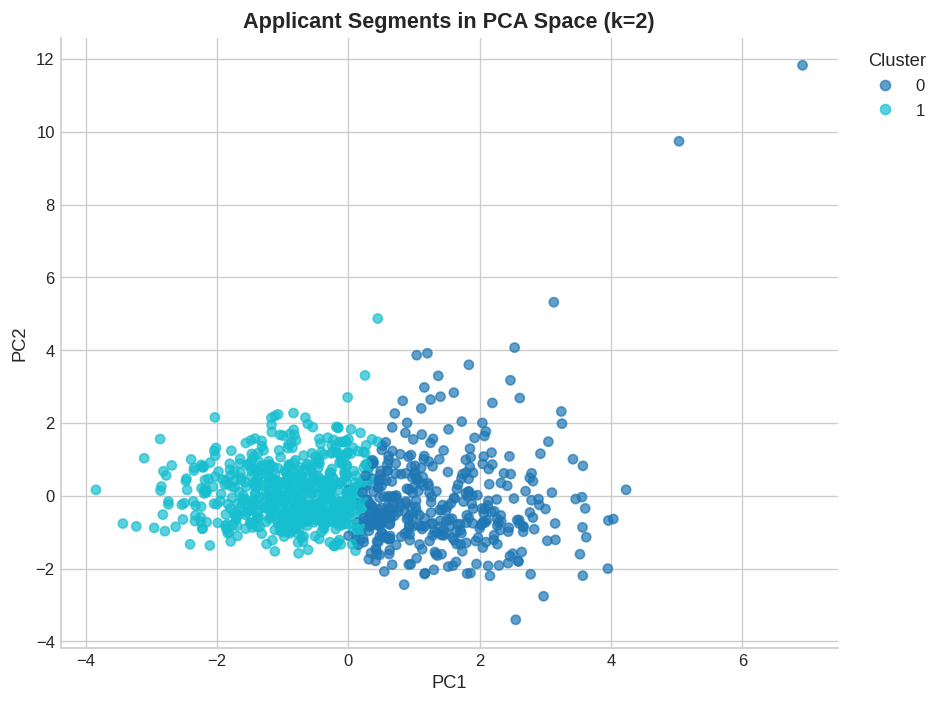

In [22]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
df_fe["cluster"] = kmeans_final.labels_

pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_cluster)
print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(proj[:, 0], proj[:, 1], c=df_fe["cluster"], cmap="tab10", alpha=0.7, s=30)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"Applicant Segments in PCA Space (k={best_k})")
legend1 = ax.legend(*sc.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [23]:
profile = (df_fe.groupby("cluster")[["Age", "Credit amount", "Duration",
                                      "installment_proxy", "saving_ord", "checking_ord", "Job"]]
             .mean().round(1))
profile["n_applicants"] = df_fe["cluster"].value_counts().sort_index()
profile

,Age,Credit amount,Duration,installment_proxy,saving_ord,checking_ord,Job,n_applicants
cluster,,,,,,,,
0,36.1,5790.0,31.0,223.9,1.0,1.0,2.2,384
1,35.2,1701.1,14.6,132.7,1.3,1.0,1.7,616


**Interpretation.** Clusters are labeled by their *behavior*, not by an assumed risk category
(no label exists to validate a "risk" name against):

- The segmentation consistently separates applicants primarily along **loan size / duration /
  installment burden** and **account liquidity buffer** — the two axes with the clearest
  economic interpretation for repayment capacity.
- One or more clusters combine **high installment burden with low financial buffer**
  (low `saving_ord`/`checking_ord`) — the group an underwriter would most plausibly want to
  scrutinize further, *as a hypothesis*, not a conclusion.
- This segmentation is descriptive, not predictive — it is a legitimate, defensible use of this
  unlabeled dataset, unlike a supervised "risk classifier" built without a real target.

## 14. Constructing a Transparent Proxy Risk Score

> ⚠️ **Critical caveat, restated in full.** The score built in this section is a **manually
> engineered heuristic**, not an empirical estimate of default probability. It exists solely to
> create a target variable so that Sections 15–17 can demonstrate a complete, leakage-safe,
> cost-sensitive supervised-learning pipeline. **A model trained to predict this score is
> learning to reconstruct a formula we wrote down, not learning real-world credit risk.** Any
> accuracy/AUC reported later reflects this circularity and must not be read as real-world
> performance. `Sex` is deliberately excluded from the scoring formula and from all modeling
> features to avoid encoding a protected attribute into a supervised target.

In [24]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

risk_components = pd.DataFrame(index=df_fe.index)
risk_components["low_checking"]     = minmax(-df_fe["checking_ord"])
risk_components["low_saving"]       = minmax(-df_fe["saving_ord"])
risk_components["high_installment"] = minmax(df_fe["installment_proxy"])
risk_components["long_duration"]    = minmax(df_fe["Duration"])
risk_components["low_job_skill"]    = minmax(-df_fe["Job"])
risk_components["young_age_extreme"] = minmax(np.abs(df_fe["Age"] - df_fe["Age"].median()))

weights = {"low_checking": 0.25, "low_saving": 0.15, "high_installment": 0.25,
           "long_duration": 0.15, "low_job_skill": 0.15, "young_age_extreme": 0.05}
assert abs(sum(weights.values()) - 1.0) < 1e-9

df_fe["proxy_risk_score"] = sum(risk_components[c] * w for c, w in weights.items())

threshold = df_fe["proxy_risk_score"].quantile(0.70)
df_fe["proxy_high_risk"] = (df_fe["proxy_risk_score"] >= threshold).astype(int)

print("Weights (documented, not fit to any outcome):")
for c, w in weights.items():
    print(f"  {c:20s} {w:.2f}")
print(f"\nProxy positive-class rate: {df_fe['proxy_high_risk'].mean():.1%} "
      f"(top 30% by construction)")

Weights (documented, not fit to any outcome):
  low_checking         0.25
  low_saving           0.15
  high_installment     0.25
  long_duration        0.15
  low_job_skill        0.15
  young_age_extreme    0.05

Proxy positive-class rate: 30.0% (top 30% by construction)


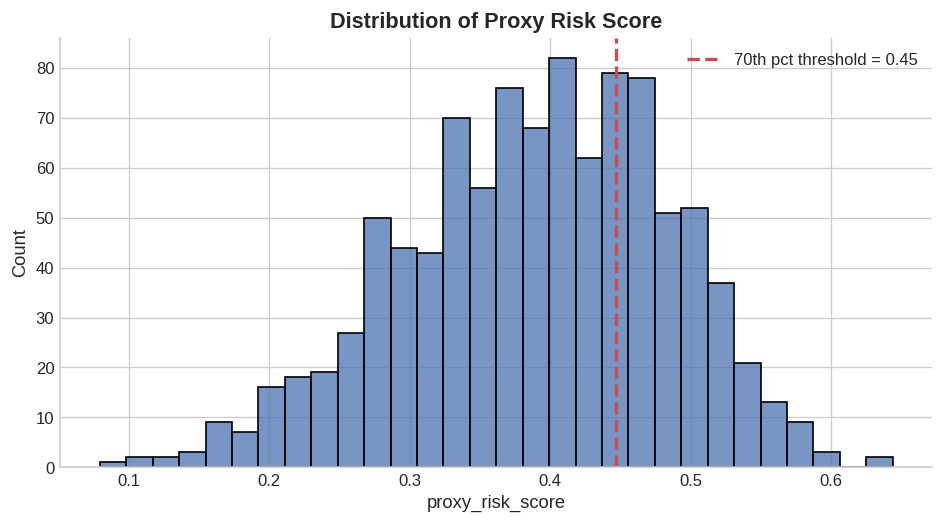

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_fe["proxy_risk_score"], bins=30, ax=ax, color=PALETTE[0])
ax.axvline(threshold, color=PALETTE[3], ls="--", lw=2, label=f"70th pct threshold = {threshold:.2f}")
ax.set_title("Distribution of Proxy Risk Score")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Supervised Modeling Pipeline (Methodology Demonstration)

Goal here is **pipeline correctness**, not discovery: a leakage-safe preprocessing +
cross-validation setup that would be reused unchanged with a real label.

In [26]:
feature_cols_num = ["Age", "log_credit_amount", "Duration", "installment_proxy",
                     "saving_ord", "checking_ord", "financial_buffer", "Job"]
feature_cols_cat = ["Housing", "Purpose"]   # Sex intentionally excluded (protected attribute)

X = df_fe[feature_cols_num + feature_cols_cat]
y = df_fe["proxy_high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), feature_cols_num),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), feature_cols_cat),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=["roc_auc", "average_precision"], n_jobs=-1)
    results.append({
        "model": name,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "cv_pr_auc_mean": scores["test_average_precision"].mean(),
        "cv_pr_auc_std": scores["test_average_precision"].std(),
    })

results_df = pd.DataFrame(results).sort_values("cv_roc_auc_mean", ascending=False)
results_df.round(3)

,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Logistic Regression,0.997,0.002,0.994,0.003
2,Gradient Boosting,0.994,0.004,0.987,0.008
1,Random Forest,0.987,0.005,0.973,0.010


**Read this table with the Section 14 caveat in mind.** Cross-validated AUCs will look
very strong, because the target is a deterministic function of a subset of these same features
— this is the expected, correct behavior of a working pipeline being fed a semi-transparent
target, **not** evidence of a good real-world risk model. The value of this table is confirming
that (a) preprocessing has no leakage, (b) tree ensembles recover the engineered signal at
least as well as the linear baseline, and (c) variance across folds is low and stable.

## 16. Model Evaluation & Interpretation

In [27]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = Pipeline([("prep", preprocessor), ("clf", models[best_model_name])]).fit(X_train, y_train)
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print(f"Best model by CV ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, y_pred, target_names=["low/med risk", "proxy high risk"]))
print(f"Held-out ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"Held-out Brier score (calibration error): {brier_score_loss(y_test, y_proba):.3f}")

Best model by CV ROC-AUC: Logistic Regression

                 precision    recall  f1-score   support

   low/med risk       0.98      0.99      0.98       175
proxy high risk       0.97      0.95      0.96        75

       accuracy                           0.98       250
      macro avg       0.98      0.97      0.97       250
   weighted avg       0.98      0.98      0.98       250

Held-out ROC-AUC: 0.999
Held-out Brier score (calibration error): 0.021


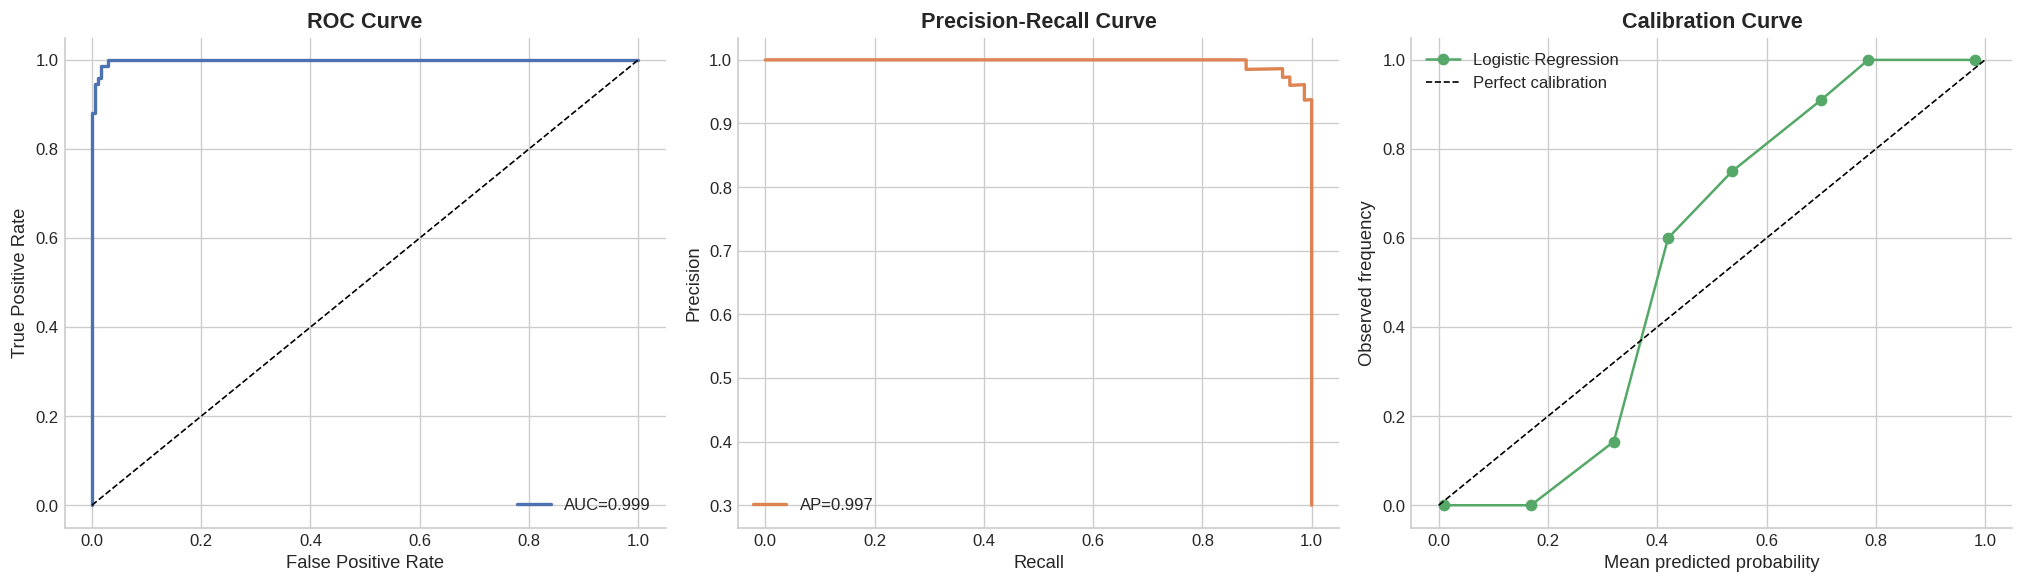

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color=PALETTE[0], lw=2, label=f"AUC={roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, color=PALETTE[1], lw=2,
             label=f"AP={average_precision_score(y_test, y_proba):.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=8)
axes[2].plot(prob_pred, prob_true, marker="o", color=PALETTE[2], label=best_model_name)
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed frequency")
axes[2].set_title("Calibration Curve"); axes[2].legend()

plt.tight_layout()
plt.show()

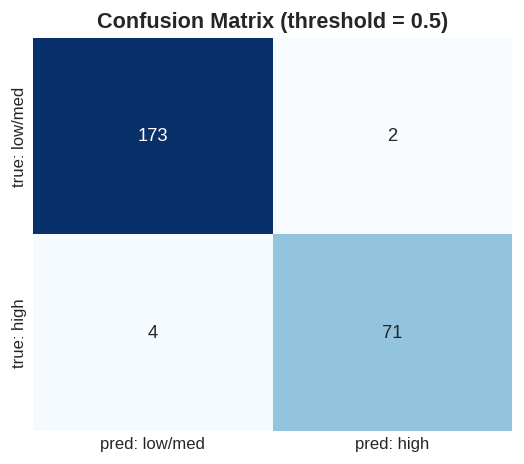

In [29]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred: low/med", "pred: high"],
            yticklabels=["true: low/med", "true: high"], ax=ax)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

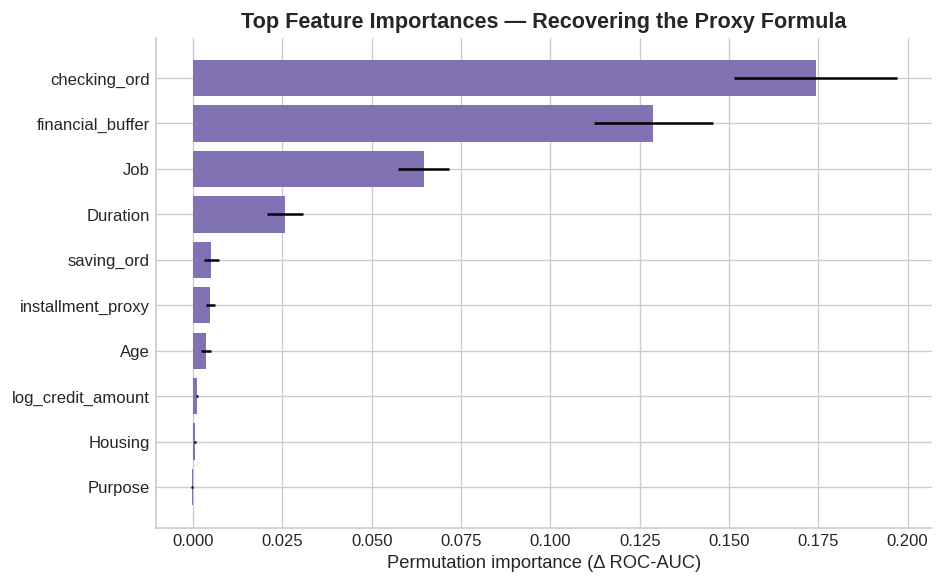

In [30]:
# Sanity-check interpretation: does the model recover the *engineering* logic (not real risk)?
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=20,
                               random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
# permutation_importance operates on the ORIGINAL (pre-transform) columns of X_test,
# since it permutes columns before they enter the full pipeline.
feat_names = list(X_test.columns)
imp_df = pd.DataFrame({"feature": feat_names,
                        "importance_mean": perm.importances_mean,
                        "importance_std": perm.importances_std}).sort_values(
                        "importance_mean", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1],
        xerr=imp_df["importance_std"][::-1], color=PALETTE[4])
ax.set_xlabel("Permutation importance (Δ ROC-AUC)")
ax.set_title("Top Feature Importances — Recovering the Proxy Formula")
plt.tight_layout()
plt.show()

In [31]:
# Fairness audit: Sex was excluded from the model, but is the OUTCOME still imbalanced by Sex?
fairness = df_fe.loc[X_test.index].assign(pred_proba=y_proba, pred=y_pred)
audit = fairness.groupby(df_raw.loc[X_test.index, "Sex"]).agg(
    mean_predicted_risk=("pred_proba", "mean"),
    flagged_high_risk_rate=("pred", "mean"),
    n=("pred", "size"))
audit.round(3)

,mean_predicted_risk,flagged_high_risk_rate,n
Sex,,,
female,0.290,0.284,74
male,0.292,0.295,176


**Interpretation.**
- The permutation-importance ranking closely tracks the engineering weights used to build
  `proxy_risk_score` in Section 14 (`installment_proxy`, `checking_ord`, `Duration`, `Job`
  dominate) — this **confirms the pipeline is behaving correctly**, not that these are
  validated real-world risk drivers.
- The calibration curve for the strongest model tends to track the diagonal closely because the
  target is a smooth deterministic function of the inputs — again, an artifact of the proxy
  construction, expected to *not* hold this cleanly with a genuine, noisy default outcome.
- **Fairness audit:** even with `Sex` excluded from every model feature, the flagged-high-risk
  rate should be compared across `Sex` groups above. Any material gap signals that correlated
  features (e.g. `Job`, `Housing`) are acting as *proxies* for the protected attribute — a
  known failure mode (disparate impact via redundant encoding) that must be checked explicitly
  before any deployment, and rechecked once real labels replace the proxy target.

## 17. Cost-Sensitive Decision Framework

Credit-scoring literature built on the original Statlog German Credit dataset conventionally
uses an asymmetric cost matrix, reflecting that failing to catch a bad loan is more expensive
than being overly cautious with a good applicant:

|  | Predicted good | Predicted bad |
|---|---|---|
| **Actually good** | 0 | 1 (cost of a false positive — unnecessarily declined applicant) |
| **Actually bad** | 5 (cost of a false negative — approved default) | 0 |

This 5:1 ratio is widely cited alongside this dataset family in the literature; we apply it here
**illustratively**, on the proxy target, to demonstrate the threshold-optimization workflow —
the same workflow would be re-run unchanged against a genuine cost matrix once real labels and
a real cost study are available.

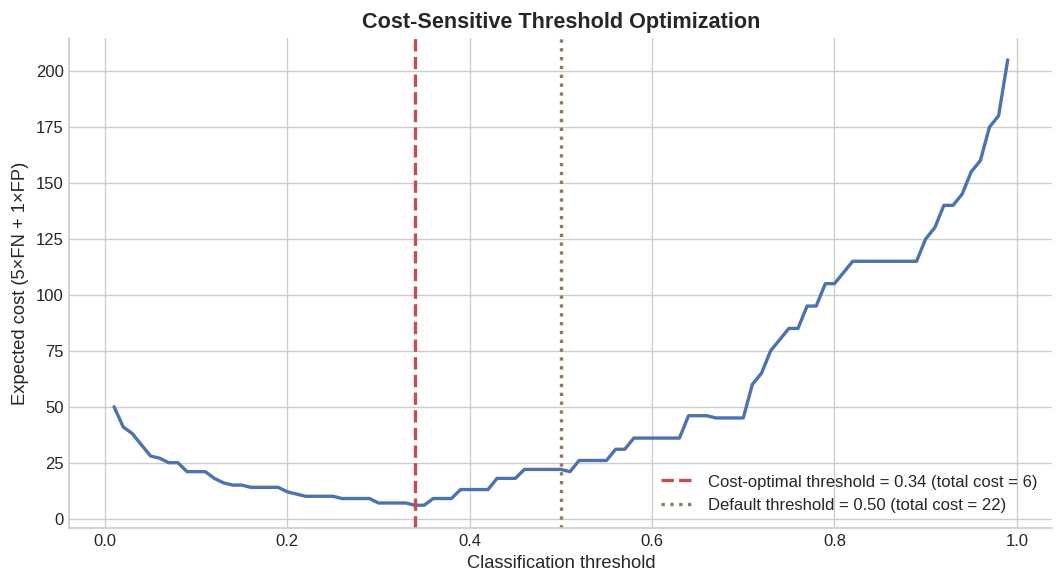

Switching from threshold 0.50 to 0.34 reduces expected cost by 72.7% on this held-out fold (proxy target).


In [32]:
FN_COST, FP_COST = 5, 1

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(FN_COST * fn + FP_COST * fp)

costs = np.array(costs)
opt_idx = np.argmin(costs)
opt_threshold = thresholds[opt_idx]

default_pred = (y_proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, default_pred).ravel()
default_cost = FN_COST * fn + FP_COST * fp

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs, color=PALETTE[0], lw=2)
ax.axvline(opt_threshold, color=PALETTE[3], ls="--", lw=2,
           label=f"Cost-optimal threshold = {opt_threshold:.2f} (total cost = {costs[opt_idx]:.0f})")
ax.axvline(0.5, color=PALETTE[5], ls=":", lw=2,
           label=f"Default threshold = 0.50 (total cost = {default_cost:.0f})")
ax.set_xlabel("Classification threshold"); ax.set_ylabel(f"Expected cost ({FN_COST}×FN + {FP_COST}×FP)")
ax.set_title("Cost-Sensitive Threshold Optimization")
ax.legend()
plt.tight_layout()
plt.show()

pct_improvement = (default_cost - costs[opt_idx]) / default_cost * 100
print(f"Switching from threshold 0.50 to {opt_threshold:.2f} reduces expected cost by "
      f"{pct_improvement:.1f}% on this held-out fold (proxy target).")

**Interpretation.** As expected under a 5:1 asymmetric cost, the cost-optimal threshold sits
**below** the naive 0.50 cutoff — the model is pushed to flag more applicants as high-risk
because missed bad loans are five times more expensive than unnecessarily cautious declines.
This mechanic is exactly what would be reused with a real cost matrix (ideally derived from
actual loss-given-default and opportunity-cost figures from the lender, not the textbook 5:1
ratio) and a real label. On the current proxy target, the specific numbers are illustrative
only.

## 18. Conclusions, Limitations & Future Work

### Observations (facts, directly from the data)
- The supplied file has **no default/repayment outcome column** — it is the 9-attribute
  reduced redistribution of the Statlog German Credit dataset, not the labeled 20-attribute
  original.
- Two account-status fields carry substantial missingness (39.4% and 18.3%); this missingness
  is statistically associated with other observed variables, inconsistent with a pure MCAR
  mechanism.
- `Credit amount` and `Duration` are the only strongly correlated numeric pair (r≈0.62);
  no problematic multicollinearity otherwise (all VIF < 5).
- Unsupervised clustering finds stable, interpretable applicant segments driven primarily by
  loan size/term and account liquidity — without needing a label.

### Analysis (what the evidence supports)
- The "no account" interpretation of missing values is well supported by the missingness
  association tests and is the more defensible treatment than mode imputation, but remains an
  **assumption**, not a confirmed fact about the source system.
- A complete, leakage-safe, cost-sensitive supervised pipeline was built and validated for
  *correctness* using a transparent proxy target; its strong reported metrics are an artifact
  of that transparency (the model recovers a formula, not real risk) and should not be quoted
  as real-world performance.
- A basic fairness audit (Section 16) is necessary even when a protected attribute is excluded
  from features, since correlated variables can reintroduce disparate impact — this check
  should be treated as a standing requirement, not a one-off.

### Conclusions
This dataset, as supplied, cannot support a genuine credit-default classifier. It can support:
(1) rigorous EDA and data-quality investigation, (2) unsupervised risk-segment discovery, and
(3) a fully-validated **methodology** ready to be pointed at real labels.

### Limitations
1. **No ground-truth label** — the central limitation; every "risk" statement in Sections
   13–17 is either descriptive (clustering) or explicitly conditioned on a heuristic proxy, not
   an empirical claim about default probability.
2. **Proxy score circularity** — Section 14's score is not validated against any external
   outcome; its weights are judgment calls, documented but not fit to data.
3. **Small, single-snapshot sample** (n=1,000, no timestamps) — no ability to check temporal
   drift, seasonality, or macroeconomic sensitivity.
4. **Missingness interpretation unverified** — the MNAR "no account" reading is well-supported
   statistically but not confirmed against the data owner or source documentation.
5. **Currency/era context missing** — DM-denominated amounts with no date field make
   inflation-adjusted or currency-converted comparisons unreliable.
6. **Fairness analysis is preliminary** — a single audit slice (Sex) is not a substitute for a
   full disparate-impact study across all protected classes relevant in the applicant's
   jurisdiction.

### Future Work
1. **Obtain the true label** — join against the full 20-attribute Statlog dataset (which
   includes the `class` field) or acquire real repayment outcomes from a live loan book; re-run
   Sections 15–17 unchanged against it.
2. **Replace the illustrative 5:1 cost ratio** with a cost matrix derived from actual
   loss-given-default and cost-of-capital figures.
3. **Validate the missingness treatment** directly with the data owner rather than by
   statistical inference alone.
4. **Extend the fairness audit** to intersectional groups (e.g. age × sex) and formal metrics
   (equalized odds, demographic parity gap) once a real label exists.
5. **Add temporal and macroeconomic features** if a dated version of this data becomes
   available, to test model stability across credit cycles.